**Name: Abeer Fatima**

**Roll no: 22F-BSAI-38**

**Department: BSAI (A1)**

**Subject: Deep Learning**

**Teacher: Sir Hamza**

# **GENERATION 2 — LSTM / Bi-LSTM / GRU**

## **Imports**

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import time

In [ ]:
df=pd.read_csv("/content/Clean_Encoded-Data.csv")

In [ ]:
df.shape

(167596, 83)

# **Train-Test Split + Scaling**

In [ ]:
X = df.drop("hospital_death", axis=1)
y = df["hospital_death"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Convert to Sequences**

Simulate patient "timelines" using sliding windows:

In [ ]:
def create_sequences(X, y, timesteps=5):
    Xs, ys = [], []
    for i in range(len(X) - timesteps):
        Xs.append(X[i:i+timesteps])
        ys.append(y.iloc[i+timesteps])
    return np.array(Xs), np.array(ys)

timesteps = 5

X_train_seq, y_train_seq = create_sequences(X_train, y_train, timesteps)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, timesteps)

# **LSTM MODEL**

In [ ]:
def build_lstm():
    model = models.Sequential([
        layers.LSTM(64, return_sequences=False, input_shape=(timesteps, X_train.shape[1])),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

## **Train LSTM**

In [ ]:
lstm = build_lstm()

lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

start = time.time()

history_lstm = lstm.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=500,
    batch_size=256,
    callbacks=[callbacks.EarlyStopping(patience=20, restore_best_weights=True)],
    verbose=1
)

lstm_time = time.time() - start

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.4990 - loss: 0.6954 - precision: 0.4988 - recall: 0.4935 - val_accuracy: 0.5017 - val_loss: 0.6937 - val_precision: 0.5027 - val_recall: 0.4376
Epoch 2/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5141 - loss: 0.6927 - precision: 0.5139 - recall: 0.5143 - val_accuracy: 0.5045 - val_loss: 0.6938 - val_precision: 0.5043 - val_recall: 0.6216
Epoch 3/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5220 - loss: 0.6916 - precision: 0.5213 - recall: 0.5339 - val_accuracy: 0.5019 - val_loss: 0.6941 - val_precision: 0.5030 - val_recall: 0.4346
Epoch 4/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5301 - loss: 0.6900 - precision: 0.5298 - recall: 0.5312 - val_accuracy: 0.5033 - val_loss: 0.6945 - val_precision: 0.5036 - val_recall: 0.5589
Epoch 5/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5390 - loss: 0.6883 - precision: 0.5386 - recall: 0.5429 - val_accuracy: 0.5006 - val_los

# **Bi-LSTM MODEL**

In [ ]:
def build_bilstm():
    model = models.Sequential([
        layers.Bidirectional(
            layers.LSTM(64, return_sequences=False),
            input_shape=(timesteps, X_train.shape[1])
        ),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

## **Train Bi-LSTM**

In [ ]:
bilstm = build_bilstm()

bilstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

start = time.time()

history_bilstm = bilstm.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=500,
    batch_size=256,
    callbacks=[callbacks.EarlyStopping(patience=20, restore_best_weights=True)],
    verbose=1
)

bilstm_time = time.time() - start

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5002 - loss: 0.6954 - precision_1: 0.5000 - recall_1: 0.5041 - val_accuracy: 0.4988 - val_loss: 0.6937 - val_precision_1: 0.4991 - val_recall_1: 0.2758
Epoch 2/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5189 - loss: 0.6921 - precision_1: 0.5193 - recall_1: 0.5037 - val_accuracy: 0.5002 - val_loss: 0.6941 - val_precision_1: 0.5011 - val_recall_1: 0.4133
Epoch 3/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5283 - loss: 0.6903 - precision_1: 0.5288 - recall_1: 0.5166 - val_accuracy: 0.5067 - val_loss: 0.6946 - val_precision_1: 0.5080 - val_recall_1: 0.4700
Epoch 4/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5436 - loss: 0.6874 - precision_1: 0.5437 - recall_1: 0.5393 - val_accuracy: 0.4995 - val_loss: 0.6964 - val_precision_1: 0.5003 - val_recall_1: 0.5018
Epoch 5/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5523 - loss: 0.6839 - precision_1: 0.5521 - recall_1: 0.

# **GRU MODEL**

In [ ]:
def build_gru():
    model = models.Sequential([
        layers.GRU(64, return_sequences=False, input_shape=(timesteps, X_train.shape[1])),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

## **Train GRU**

In [ ]:
gru = build_gru()

gru.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

start = time.time()

history_gru = gru.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=500,
    batch_size=256,
    callbacks=[callbacks.EarlyStopping(patience=20, restore_best_weights=True)],
    verbose=1
)

gru_time = time.time() - start

Epoch 1/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5000 - loss: 0.6976 - precision_2: 0.4998 - recall_2: 0.5016 - val_accuracy: 0.5017 - val_loss: 0.6943 - val_precision_2: 0.5026 - val_recall_2: 0.4621
Epoch 2/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5110 - loss: 0.6936 - precision_2: 0.5109 - recall_2: 0.5074 - val_accuracy: 0.5026 - val_loss: 0.6942 - val_precision_2: 0.5027 - val_recall_2: 0.6114
Epoch 3/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5172 - loss: 0.6923 - precision_2: 0.5168 - recall_2: 0.5237 - val_accuracy: 0.5051 - val_loss: 0.6943 - val_precision_2: 0.5066 - val_recall_2: 0.4458
Epoch 4/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5244 - loss: 0.6914 - precision_2: 0.5247 - recall_2: 0.5144 - val_accuracy: 0.4967 - val_loss: 0.6951 - val_precision_2: 0.4972 - val_recall_2: 0.4561
Epoch 5/500
419/419 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5284 - loss: 0.6904 - precision_2: 0.5288 - recall_2: 0.

# **Evaluation Function (for all models)**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, X_test, y_test, name):
    y_pred = (model.predict(X_test) > 0.5).astype(int)

    print(f"\n===== {name} =====")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1-Score :", f1_score(y_test, y_pred))

## **Run Evaluation**

In [ ]:
evaluate_model(lstm, X_test_seq, y_test_seq, "LSTM")
evaluate_model(bilstm, X_test_seq, y_test_seq, "Bi-LSTM")
evaluate_model(gru, X_test_seq, y_test_seq, "GRU")

1048/1048 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step

===== LSTM =====
Accuracy : 0.5006713411905117
Precision: 0.5007717602845446
Recall   : 0.4452798663324979
F1-Score : 0.4713983385451215
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step

===== Bi-LSTM =====
Accuracy : 0.5026107712964344
Precision: 0.5046948356807511
Recall   : 0.2822532521780642
F1-Score : 0.36203597397627246
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

===== GRU =====
Accuracy : 0.49724004177234077
Precision: 0.49773287333661903
Recall   : 0.6026375462465688
F1-Score : 0.5451846253508962


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, X_train, y_train, X_test, y_test, name):

    # Predictions
    y_pred_train = (model.predict(X_train) > 0.5).astype(int)
    y_pred_test  = (model.predict(X_test) > 0.5).astype(int)

    print(f"\n================ {name} ================")

    print("\n--- TRAIN RESULTS ---")
    print("Accuracy :", accuracy_score(y_train, y_pred_train))
    print("Precision:", precision_score(y_train, y_pred_train))
    print("Recall   :", recall_score(y_train, y_pred_train))
    print("F1-Score :", f1_score(y_train, y_pred_train))

    print("\n--- TEST RESULTS ---")
    print("Accuracy :", accuracy_score(y_test, y_pred_test))
    print("Precision:", precision_score(y_test, y_pred_test))
    print("Recall   :", recall_score(y_test, y_pred_test))
    print("F1-Score :", f1_score(y_test, y_pred_test))

In [ ]:
evaluate_model(lstm, X_train_seq, y_train_seq, X_test_seq, y_test_seq, "LSTM")
evaluate_model(bilstm, X_train_seq, y_train_seq, X_test_seq, y_test_seq, "Bi-LSTM")
evaluate_model(gru, X_train_seq, y_train_seq, X_test_seq, y_test_seq, "GRU")

4190/4190 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

================ LSTM ================

--- TRAIN RESULTS ---
Accuracy : 0.5205450843209941
Precision: 0.5234902763561924
Recall   : 0.457775788767062
F1-Score : 0.48843261310731767

--- TEST RESULTS ---
Accuracy : 0.5006713411905117
Precision: 0.5007717602845446
Recall   : 0.4452798663324979
F1-Score : 0.4713983385451215
4190/4190 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

================ Bi-LSTM ================

--- TRAIN RESULTS ---
Accuracy : 0.519761917193129
Precision: 0.5348506775424287
Recall   : 0.3032296561497725
F1-Score : 0.38703351104341205

--- TEST RESULTS ---
Accuracy : 0.5026107712964344
Precision: 0.5046948356807511
Recall   : 0.2822532521780642
F1-Score : 0.36203597397627246
4190/4190 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

================ GRU ================

--- TRAIN RESULTS ---
Accuracy : 0.52598996054

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [ ]:
def plot_curves(history, title):
    plt.figure(figsize=(12,4))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(title + " Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(title + " Loss")
    plt.legend()

    plt.show()

In [ ]:
def evaluate_all(model, history, X_train, y_train, X_test, y_test, name):

    # Predictions
    y_pred_train = (model.predict(X_train) > 0.5).astype(int)
    y_pred_test  = (model.predict(X_test) > 0.5).astype(int)

    print(f"\n================ {name} ================")

    print("\n--- TRAIN ACC ---")
    print(accuracy_score(y_train, y_pred_train))

    print("\n--- TEST ACC ---")
    print(accuracy_score(y_test, y_pred_test))

    # Confusion Matrix (TEST)
    plot_confusion_matrix(y_test, y_pred_test, name + " Confusion Matrix")

    # Curves
    plot_curves(history, name)

4190/4190 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

================ LSTM ================

--- TRAIN ACC ---
0.5205450843209941

--- TEST ACC ---
0.5006713411905117


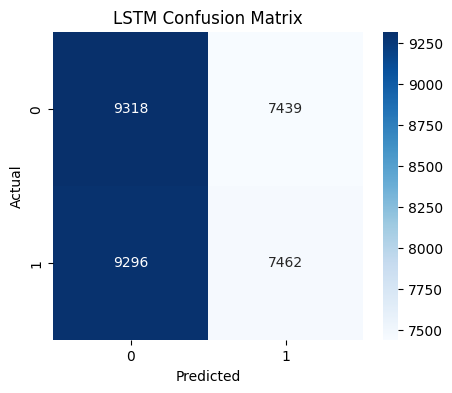

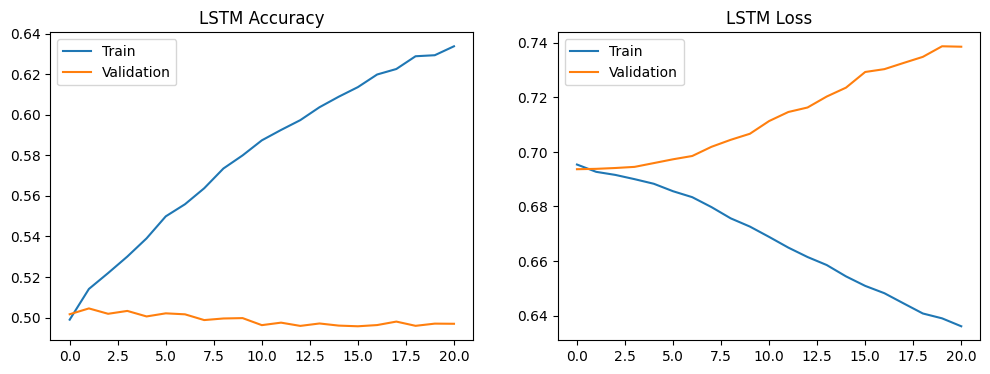

In [ ]:
evaluate_all(
    lstm,
    history_lstm,
    X_train_seq, y_train_seq,
    X_test_seq, y_test_seq,
    "LSTM"
)

4190/4190 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step

================ Bi-LSTM ================

--- TRAIN ACC ---
0.519761917193129

--- TEST ACC ---
0.5026107712964344


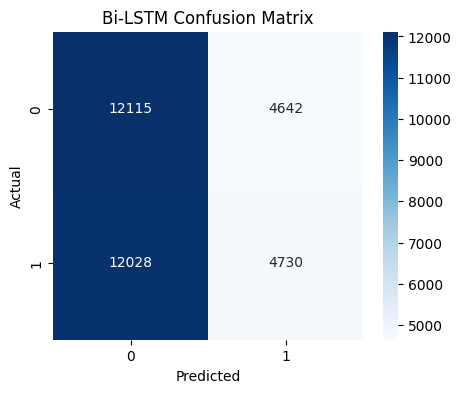

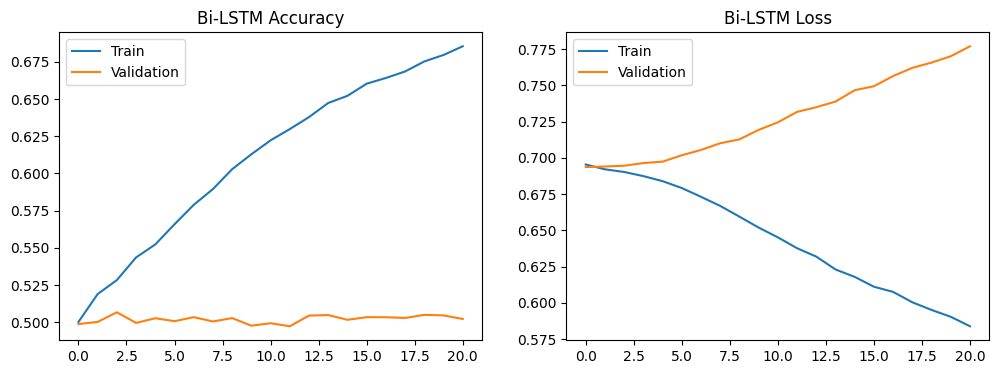

In [ ]:
evaluate_all(
    bilstm,
    history_bilstm,
    X_train_seq, y_train_seq,
    X_test_seq, y_test_seq,
    "Bi-LSTM"
)

4190/4190 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step
1048/1048 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

================ GRU ================

--- TRAIN ACC ---
0.5259899605432943

--- TEST ACC ---
0.49724004177234077


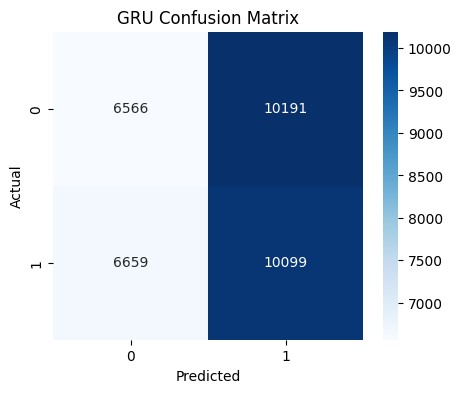

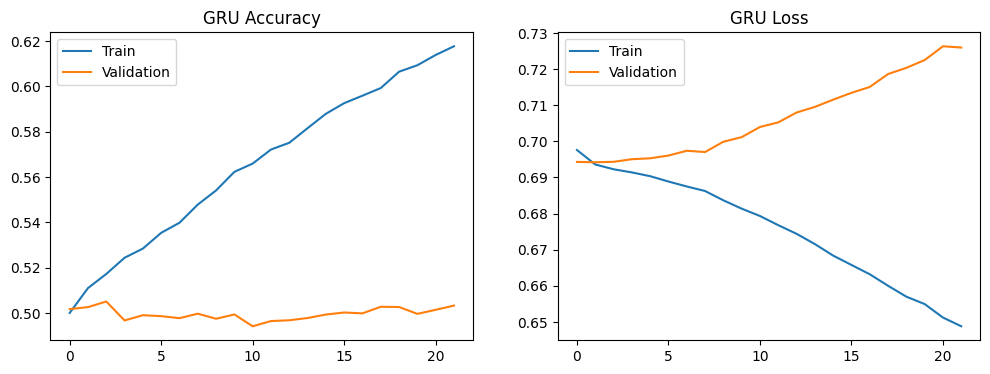

In [ ]:
evaluate_all(
    gru,
    history_gru,
    X_train_seq, y_train_seq,
    X_test_seq, y_test_seq,
    "GRU"
)